---
title: How to speed up an AB test
description: Разбор некоторых методов ускорения AB тестов
date: "2025-04-23"
categories: [research]
code-fold: true
---

# Theory

## Введение

Для простоты остановимся на самом типичном варианте теста, где мы хотим ответить стало ли в среднем лучше, более формально можно это записать так: 

* $H_0: E(X_T) = E(X_C)$ - т.е. нулевая гипотеза, что среднее значение метрики X в тесте (T) и контроле (C) равны
* $H_1: E(X_T) > E(X_C)$ - альтернативная гипотеза, что среднее значение метрики X в тесте (T) больше чем в контроле (C)

Для такой постановки хорошо подходить t-test, он собирается из следующих формулок: 

* $E(X_T) \approx \mathcal{N}(\mu_1, \frac{\sigma_T^2}{N_T})$ - среднее в тесте распределено нормально 
* $E(X_C) \approx \mathcal{N}(\mu_1, \frac{\sigma_C^2}{N_C})$ - среднее в контроле распределено нормально 

Тогда если все предпосылки верны тестируемая гипотеза $H_0$ выглядит так: 

$E(X_T) - E(X_C) \overset{H_0}{\approx} \mathcal{N}\left(0, \frac{\sigma_T^2}{N_T} + \frac{\sigma_C^2}{N_C}\right)$

Для приближения к практике сразу перейдем от абсолютной постановки задачи к относительной, потому что обычно итоги мы считаем в процентах по формулке $\frac{E(X_T)-E(X_C)}{E(X_C)}$, оценивать эту метрику по идеям выше нельзя, ибо нужно правильно учитывать оценки среднего и дисперсии для дроби ([подробнее по ссылке](https://www.stat.cmu.edu/~hseltman/files/ratio.pdf)), нас оттуда интересует такое разложение: 

$Var(R/S) = \frac{\mu_R^2}{\mu_S^2}[\frac{\sigma_R^2}{\mu_R^2} - 2 \frac{Cov(R, S)}{\mu_r\mu_S} + \frac{\sigma_S^2}{\mu_S^2}]$

Гуглить подробности в контексте аб можно по запросу "дельта метод", главное что теперь мы можем реализовать честную оценку итогов t-test для ситуаций, когда нам нужны оценки процентных изменений (почти всегда)

Теперь для честности посмотрим на практике пару переходов, которые я опустил, но проверить стоит: 

## "Доказательства"

### ЦПТ

Или то, почему мы говорим что если данных достаточно много, то требования t-test выполняются: 

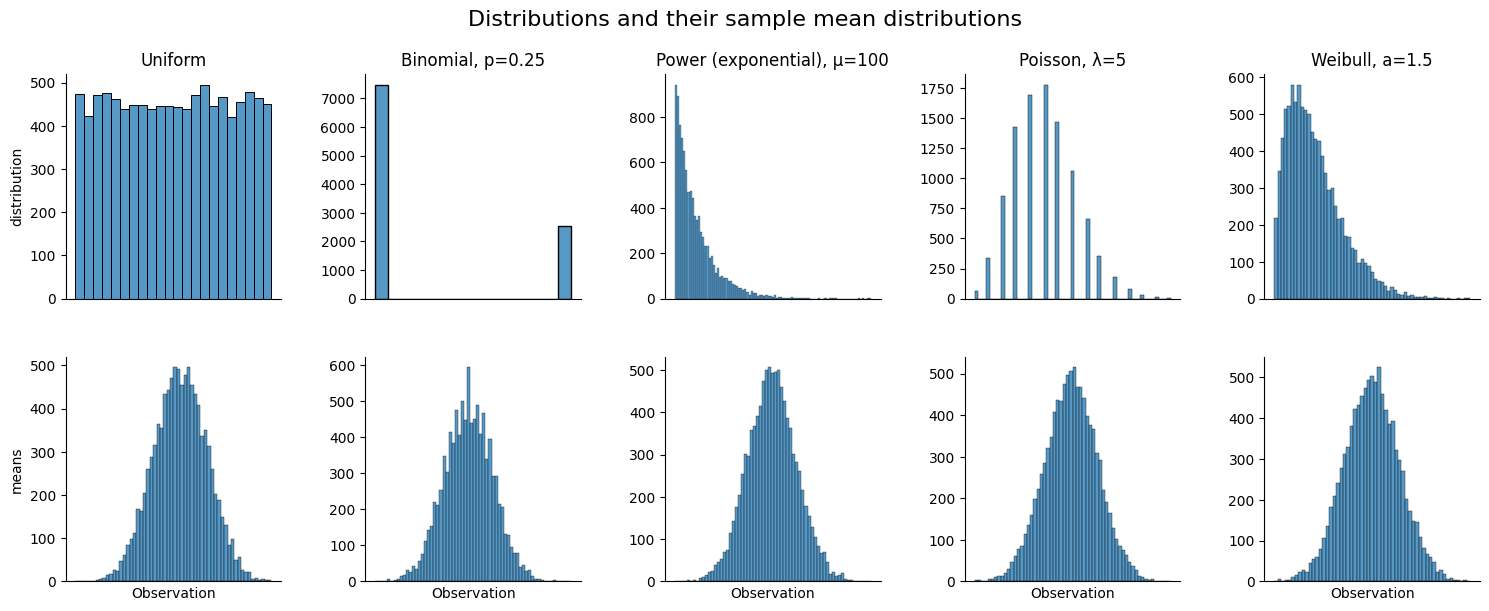

In [ ]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(20010206)

SIZE = 10_000

distributions = {
    'Uniform':np.random.rand(SIZE),
    'Binomial, p=0.25':np.random.binomial(n=1, p=0.25, size=SIZE), 
    'Power (exponential), μ=100':np.random.exponential(scale=100, size=SIZE), 
    'Poisson, λ=5': np.random.poisson(lam=5, size=SIZE),
    'Weibull, a=1.5': np.random.weibull(a=1.5, size=SIZE), 
}

dist_means = {k:np.random.choice(v, size=(SIZE, SIZE)).mean(axis=1) for k,v in distributions.items()}

dist = pd.DataFrame(distributions).assign(type='distribution')
means = pd.DataFrame(dist_means).assign(type='means')
df = pd.concat([dist, means])

df = df.melt(id_vars='type', var_name='Distribution', value_name='Observation')

g = sns.FacetGrid(df, col="Distribution", row='type', sharex=False, sharey=False)
g.map(sns.histplot, 'Observation')


# Удаление всех заголовков
g.set_titles("")

# Настройка заголовков только для первой строки
for ax, row_val in zip(g.axes[0], df['Distribution'].unique()):
    ax.set_title(row_val)

# Удаление подписей оси x
g.set(xticks=[])

# Установка подписей оси y только для первой колонки
for ax in g.axes.flatten():
    ax.set_ylabel('')

for i, ax in enumerate(g.axes[:, 0]):
    ax.set_ylabel(df['type'].unique()[i])
    
    
# Установка общего заголовка
g.figure.suptitle('Distributions and their sample mean distributions', fontsize=16, y=1.05)

plt.show()

### Дельта метод

Или то, зачем так заморачиваться а не просто делить итоги абсолютов на оценки из контроля 

In [ ]:
from collections import namedtuple
from tqdm import trange
import scipy.stats as sps
ExperimentComparisonResults = namedtuple('ExperimentComparisonResults', 
                                        ['pvalue', 'effect', 'ci_length', 'left_bound', 'right_bound'])


# Функции absolute_ttest и relative_ttest беру из статьи - https://habr.com/ru/companies/avito/articles/571094/ 
# Подход с абсолютными значениями
def absolute_ttest(control, test):
    mean_control = np.mean(control)
    mean_test = np.mean(test)
    var_mean_control  = np.var(control) / len(control)
    var_mean_test  = np.var(test) / len(test)
    
    difference_mean = mean_test - mean_control
    difference_mean_var = var_mean_control + var_mean_test
    difference_distribution = sps.norm(loc=difference_mean, scale=np.sqrt(difference_mean_var))

    left_bound, right_bound = difference_distribution.ppf([0.025, 0.975])
    ci_length = (right_bound - left_bound)
    pvalue = 2 * min(difference_distribution.cdf(0), difference_distribution.sf(0))
    effect = difference_mean
    return ExperimentComparisonResults(pvalue, effect, ci_length, left_bound, right_bound)


# Дельта метод
def relative_ttest(control, test):
    mean_control = np.mean(control)
    var_mean_control  = np.var(control) / len(control)

    difference_mean = np.mean(test) - mean_control
    difference_mean_var  = np.var(test) / len(test) + var_mean_control
    
    covariance = -var_mean_control

    relative_mu = difference_mean / mean_control
    relative_var = difference_mean_var / (mean_control ** 2) \
                    + var_mean_control * ((difference_mean ** 2) / (mean_control ** 4))\
                    - 2 * (difference_mean / (mean_control ** 3)) * covariance
    relative_distribution = sps.norm(loc=relative_mu, scale=np.sqrt(relative_var))
    left_bound, right_bound = relative_distribution.ppf([0.025, 0.975])
    
    ci_length = (right_bound - left_bound)
    pvalue = 2 * min(relative_distribution.cdf(0), relative_distribution.sf(0))
    effect = relative_mu
    return ExperimentComparisonResults(pvalue, effect, ci_length, left_bound, right_bound)



# Собственно моделирование 
SIZE = 10_000
EXPERIMENTS = 1_000
np.random.seed(20010206)

# AA тесты 
abs_wrong, rel_wrong = 0, 0

for _ in range(EXPERIMENTS):
    control = np.random.exponential(scale=100, size=SIZE)
    test = np.random.exponential(scale=100, size=SIZE)
    
    control_mean = control.mean()
    
    ## Тест в абсолютах
    abs_res = absolute_ttest(control, test)
    # Абсолюты переводим в проценты в демонстрационных целях
    abs_left, abs_right = abs_res.left_bound / control_mean, abs_res.right_bound / control_mean 
    ## Тест в относительных значениях
    rel_res = relative_ttest(control, test)
    rel_left, rel_right = rel_res.left_bound, rel_res.right_bound
    
    ## Записываем ошибки
    abs_wrong += ((abs_left > 0) or (abs_right < 0))
    rel_wrong += ((rel_left > 0) or (rel_right < 0))

print(f"Доля неверных доверительных интервалов в AA тесте: \nПодход 'в лоб':{abs_wrong/EXPERIMENTS:0.2%}\nДельта метод:{rel_wrong/EXPERIMENTS:0.2%}")

# AB тесты
abs_wrong, rel_wrong = 0, 0

for _ in range(EXPERIMENTS):
    control = np.random.exponential(scale=100, size=SIZE)
    test = np.random.exponential(scale=100, size=SIZE)
    test *= 2 
    
    control_mean = control.mean()
    
    ## Тест в абсолютах
    abs_res = absolute_ttest(control, test)
    # Абсолюты переводим в проценты в демонстрационных целях
    abs_left, abs_right = abs_res.left_bound / control_mean, abs_res.right_bound / control_mean 
    ## Тест в относительных значениях
    rel_res = relative_ttest(control, test)
    rel_left, rel_right = rel_res.left_bound, rel_res.right_bound
    
    ## Записываем ошибки
    abs_wrong += ((abs_left > 1) or (abs_right < 1))
    rel_wrong += ((rel_left > 1) or (rel_right < 1))

print(f"Доля неверных доверительных интервалов в AB тесте: \nПодход 'в лоб':{abs_wrong/EXPERIMENTS:0.2%}\nДельта метод:{rel_wrong/EXPERIMENTS:0.2%}")

Доля неверных доверительных интервалов в AA тесте: 
Подход 'в лоб':5.00%
Дельта метод:4.90%
Доля неверных доверительных интервалов в AB тесте: 
Подход 'в лоб':13.20%
Дельта метод:5.70%


# Контекст

Теперь перейдем в прикладную плоскость и прикинем структуру данных в простеньком AB, дабы на ней моделировать разное. 


Глобальная цель упражнения - растить мощность не завышая ошибки первого рода, то есть чаще замечать эффект когда он есть, но не говорить что он есть когда его нет. 

Давайте считать что делаем некоторый тест для приложения по доставке еды, данные предлагаю следующие: 

* Строка - пользователь в период t
* Периодов 2 - тестовый и аналогичный по продолжительности предыдущий = препериод 
* На каждого пользователя в период t собираем метрики: 
    * Количество дней со входом в приложение 
    * Выручка 
    * Количество транзакций
* Также на каждого пользователя нам известна его группа в тесте 

In [56]:
import numpy as np 
import pandas as pd 
import seaborn as sns

USERS = 10_000 # сколько людей в группе
UPLIFT = 1.01 # относительный прирост выручки
DROPUT = 0.3 # доля тех, кто был в тесте но не был на препериоде сюда попадают новички и влияние retention 
np.random.seed(20010206)

# Функция для создания взаимосвязанных данных
def make_corr_data(data1, data2, coeff):
    return coeff * data1 + (1 - coeff) * data2

## Метрики в период теста
# Выручка - сюда вносим аплифт чтобы быть уверенными в результатах
revenue_control = np.random.exponential(scale=2_000, size=USERS)
revenue_treated = np.random.exponential(scale=2_000 * UPLIFT, size=USERS)

# Дни в приложении
days_control = make_corr_data(revenue_control, np.random.poisson(lam=3, size=USERS), 0.0001)
days_treated = make_corr_data(revenue_treated, np.random.poisson(lam=3, size=USERS), 0.0001)

# Количество транзакций
transactions_control = make_corr_data(revenue_control, np.random.exponential(scale=2, size=USERS), 0.0005)
transactions_treated = make_corr_data(revenue_treated, np.random.exponential(scale=2, size=USERS), 0.0005)

# Итоговый датафрейм
test_treated = pd.DataFrame({
    'uid':np.arange(USERS), 
    'revenue':revenue_treated, 
    'mpdays':days_treated, 
    'transactions':transactions_treated
}).assign(exp_group='treated')
test_control = pd.DataFrame({
    'uid':np.arange(USERS, USERS*2), 
    'revenue':revenue_control, 
    'mpdays':days_control, 
    'transactions':transactions_control
}).assign(exp_group='treated')

df_post = pd.concat([test_treated, test_control]).assign(period='post')

## Метрики на препериоде (без аплифта)
# Параметр для выбытия пользователей на препериоде
dropout_indices = np.random.choice(USERS, int(USERS * DROPUT), replace=False)

# Выручка
pre_revenue_control = np.random.exponential(scale=2_000, size=USERS)
pre_revenue_treated = np.random.exponential(scale=2_000, size=USERS)

# Исключение пользователей которые дропнулись на препериоде
pre_revenue_control[dropout_indices] = np.nan
pre_revenue_treated[dropout_indices] = np.nan

# Дни в приложении
pre_days_control = make_corr_data(pre_revenue_control, np.random.poisson(lam=3, size=USERS), 0.0001)
pre_days_treated = make_corr_data(pre_revenue_treated, np.random.poisson(lam=3, size=USERS), 0.0001)

# Количество транзакций
pre_transactions_control = make_corr_data(pre_revenue_control, np.random.exponential(scale=2, size=USERS), 0.0005)
pre_transactions_treated = make_corr_data(pre_revenue_treated, np.random.exponential(scale=2, size=USERS), 0.0005)

# Формирование датафрейма для препериода
pre_treated = pd.DataFrame({
    'uid': np.arange(USERS),
    'revenue': pre_revenue_treated,
    'mpdays': pre_days_treated,
    'transactions': pre_transactions_treated
}).assign(exp_group='treated')

pre_control = pd.DataFrame({
    'uid': np.arange(USERS, USERS*2),
    'revenue': pre_revenue_control,
    'mpdays': pre_days_control,
    'transactions': pre_transactions_control
}).assign(exp_group='control')

df_pre = pd.concat([pre_treated, pre_control]).assign(period='pre')
df = pd.concat([df_pre, df_post]).fillna(0)

# Methods

## Proxy metrics

## Preprocessing

## CUPED

## CUPAC

# Источники: 

- Как улучшить ваши A/B-тесты: лайфхаки аналитиков Авито. Часть 1. [habr](https://habr.com/ru/companies/avito/articles/571094/)
- Как улучшить ваши A/B-тесты: лайфхаки аналитиков Авито. Часть 2. [habr](https://habr.com/ru/companies/avito/articles/571096/)